---
title: "Chapter 4: Similarity-Based Models"
---

::: {.callout-lo}

By the end of this chapter, you will be able to:

- Explain how a feature representation and a distance measure define what it means for examples to be similar.
- Describe how $k$-nearest neighbours makes classification and regression predictions.
- Explain how small and large values of $k$ affect underfitting and overfitting.
- Explain why feature scaling and irrelevant features matter for distance-based models.
- Describe the curse of dimensionality and its consequences for nearest-neighbour methods.
- Give a high-level description of an RBF support vector machine and the role of support vectors.
- Relate `gamma` and `C` to the fundamental trade-off and explain why they should be tuned jointly.
:::

Chapter 3 developed a workflow for choosing a model without using the test set: compare model configurations using cross-validation, refit the selected configuration on all the training data, and evaluate it once on the test set. We will now apply that workflow to models built around a familiar idea: new examples are often similar to examples we have seen before.

This chapter begins with $k$-nearest neighbours ($k$-NN), for which similarity is the prediction rule itself. We then introduce an RBF support vector machine (RBF SVM), which learns a smoother prediction rule based on similarities to selected training examples. Both models will expose an important question: **what makes two examples similar?**

::: {.callout-tip title="See also"}
The accompanying videos introduce [distance and motivation](https://youtu.be/hCa3EXEUmQk), [$k$-NN](https://youtu.be/bENDqXKJLmg), [further $k$-NN considerations](https://youtu.be/IRGbqi5S9gQ), and [RBF SVMs](https://youtu.be/ic_zqOhi020).
:::

In [19]:
#| code-fold: true
#| code-summary: "Show imports and setup"


import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mglearn
import numpy as np
import pandas as pd
import panel as pn
from sklearn.dummy import DummyClassifier
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC

sys.path.append(os.path.abspath("code"))
from plotting_functions import *
from utils import *

pn.extension()
%matplotlib inline
warnings.filterwarnings("ignore")
DATA_DIR = Path("data")

## From examples to distances

Suppose we are given labeled images of faces and asked to label a new image. One natural strategy is to find a training image that looks similar and reuse its label.

<img src="img/knn-motivation.png" width="1000">

[Image source](https://vipl.ict.ac.cn/en/database.php)

This reasoning by analogy appears in tasks such as finding related products, recommending items, and recognizing images. To turn the idea into an algorithm, however, we must say exactly how examples are represented and what we mean by *similar*.

### Feature vectors and feature space

Consider the dataset of Canadian and U.S. cities from Chapter 3. Each row contains a city's longitude, latitude, and country. We will use the coordinates to predict the country.

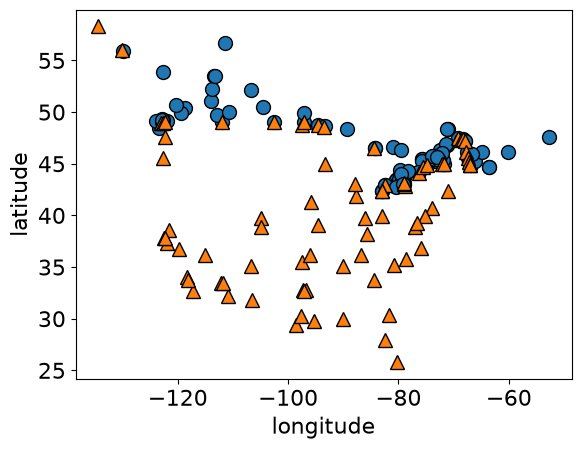

In [20]:
cities_df = pd.read_csv(DATA_DIR / "canada_usa_cities.csv")
X_cities = cities_df[["longitude", "latitude"]]
y_cities = cities_df["country"]

mglearn.discrete_scatter(X_cities.iloc[:, 0], X_cities.iloc[:, 1], y_cities)
plt.xlabel("longitude")
plt.ylabel("latitude");

In [21]:
X_cities.head()

,longitude,latitude
0,-130.0437,55.9773
1,-134.4197,58.3019
2,-123.0780,48.9854
3,-122.7436,48.9881
4,-122.2691,48.9951


The first city (row 0) has longitude $-130.0437$ and latitude $55.9773$, so we can represent it as `[-130.0437, 55.9773]`. This ordered list of feature values is its **feature vector**. Plotting all such vectors gives us a two-dimensional **feature space**, with one dimension for each feature.

The same idea applies with $d$ features: each example is a point in a $d$-dimensional feature space, even when we cannot draw it.

Now suppose a new city is at `[-123.0, 49.0]`. It seems more similar to a city at `[-122.7, 49.1]` than to one at `[-80.0, 25.0]`. A **distance measure** captures this comparison numerically: smaller distances indicate greater similarity.

Common choices include Euclidean distance (straight-line separation), Manhattan distance (movement along each coordinate), and measures based on cosine similarity (the angle between vectors). The appropriate choice depends on what the features represent.

We will begin with Euclidean distance, which we can see directly in the city plot above.

### Euclidean distance

For numerical feature vectors, one common measure of separation is **Euclidean distance**. For vectors $u = (u_1,\ldots,u_d)$ and $v=(v_1,\ldots,v_d)$, it is

$$
\operatorname{distance}(u,v)=\sqrt{\sum_{j=1}^{d}(u_j-v_j)^2}.
$$

We subtract the corresponding feature values, square the differences, add them, and take the square root. The result is always non-negative, and it is zero only when the two vectors have identical feature values.

In [22]:
two_cities = X_cities.sample(2, random_state=120)
display(two_cities)

difference = two_cities.iloc[1] - two_cities.iloc[0]
print("Feature-wise difference:")
display(difference)
print(f"Euclidean distance: {np.sqrt(np.sum(difference**2)):.4f}")

,longitude,latitude
69,-104.8253,38.8340
35,-112.0741,33.4484


Feature-wise difference:


longitude   -7.2488
latitude    -5.3856
dtype: float64

Euclidean distance: 9.0305


Scikit-learn can calculate the same quantity. Here we compare one query coordinate with five training cities; the smallest value identifies its nearest neighbour.

In [23]:
query_point = pd.DataFrame(
    {"longitude": [-80], "latitude": [25]}, index=["query"]
)
candidate_cities = X_cities.iloc[:5]
query_distances = euclidean_distances(candidate_cities, query_point).ravel()

pd.DataFrame(
    {
        "longitude": candidate_cities["longitude"],
        "latitude": candidate_cities["latitude"],
        "distance to query": query_distances,
    }
).sort_values("distance to query")

,longitude,latitude,distance to query
4,-122.2691,48.9951,48.604955
3,-122.7436,48.9881,49.014735
2,-123.0780,48.9854,49.305309
0,-130.0437,55.9773,58.855459
1,-134.4197,58.3019,63.800629


Euclidean distance is only one possible distance measure. Choosing it is a modeling decision, not a neutral calculation: it declares that squared numerical differences across the included features are a useful definition of separation.

### Distance depends on the representation

Consider a query customer and two candidates described by age and annual income. Candidate A is much closer in age; candidate B is much closer in income. If income is recorded in dollars, its much larger numerical scale dominates the Euclidean distance.

In [24]:
customers = pd.DataFrame(
    {"age": [30, 31, 45], "income_dollars": [50_000, 60_000, 50_100]},
    index=["query", "candidate A", "candidate B"],
)
raw_distances = euclidean_distances(customers.iloc[1:], customers.iloc[[0]]).ravel()
pd.DataFrame({"raw Euclidean distance": raw_distances}, index=customers.index[1:])

,raw Euclidean distance
candidate A,10000.000050
candidate B,101.118742


Candidate B is declared closer almost entirely because of income, even though the age difference is much larger. Changing dollars to thousands of dollars could reverse the result without changing the underlying customers.

This illustrates a central lesson of the chapter:

::: {.callout-important}
A distance is meaningful only relative to a feature representation. Which features we include, how we encode them, and how we scale them determine which examples count as similar.
:::

The longitude and latitude in our cities example have comparable numerical scales, which makes them convenient for building intuition. Most real datasets require deliberate preprocessing. The next chapter will show how to learn and apply scaling inside a scikit-learn pipeline so that it is handled correctly during cross-validation.

## $k$-nearest neighbours

The **$k$-nearest neighbours classifier** predicts a query example in two steps:

1. Find the $k$ training examples closest to the query according to the chosen distance.
2. Predict the class receiving the most votes among those neighbours.

The query is compared with **training examples**, never with test examples whose targets should be unknown to the model. The value $k$ is the `n_neighbors` hyperparameter in scikit-learn.

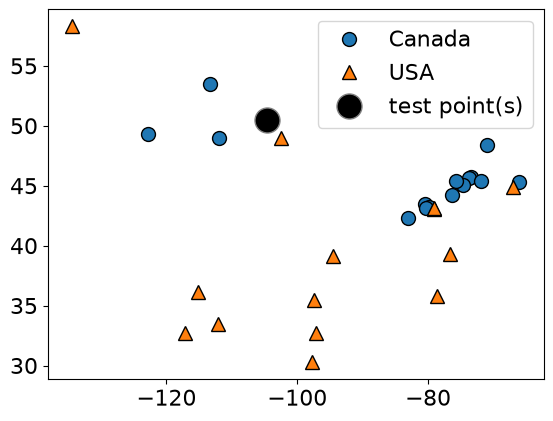

In [25]:
small_cities = cities_df.sample(30, random_state=90)
one_city = small_cities.sample(1, random_state=44)
small_train_df = pd.concat([small_cities, one_city]).drop_duplicates(keep=False)

X_small_cities = small_train_df.drop(columns=["country"]).to_numpy()
y_small_cities = small_train_df["country"].to_numpy()
test_point = one_city[["longitude", "latitude"]].to_numpy()

plot_train_test_points(
    X_small_cities,
    y_small_cities,
    test_point,
    class_names=["Canada", "USA"],
    test_format="circle",
)

With $k=1$, the closest training city determines the prediction. With $k=3$, the three closest cities vote, so the result can change.

In [26]:
for k in [1, 3]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_small_cities, y_small_cities)
    print(f"Prediction with k={k}: {model.predict(test_point)[0]}")

Prediction with k=1: USA
Prediction with k=3: Canada


### How $k$ controls model complexity

A small $k$ makes predictions highly local. A single unusual training example can change the prediction in its immediate neighborhood, producing a flexible boundary that may overfit.

A larger $k$ averages across a broader neighborhood. This produces a smoother, less flexible boundary, but a value that is too large can wash out useful local structure and underfit. At the extreme, if every training example votes, the model predicts the overall majority class everywhere, behaviour resembling a most-frequent baseline.

Try out the slider below and predict the class for each query point as you change $k$.

n_neighbors 1
n_neighbors 10
n_neighbors 9
n_neighbors 8
n_neighbors 7
n_neighbors 6
n_neighbors 5
n_neighbors 4
n_neighbors 3
n_neighbors 2
n_neighbors 1



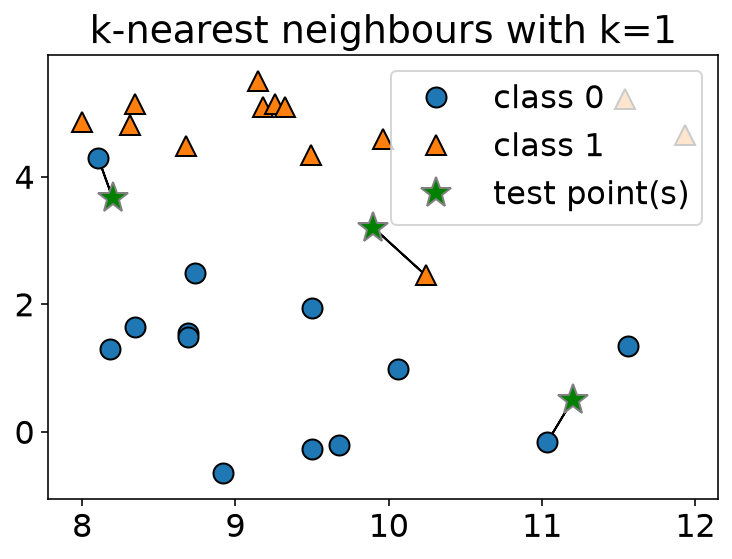
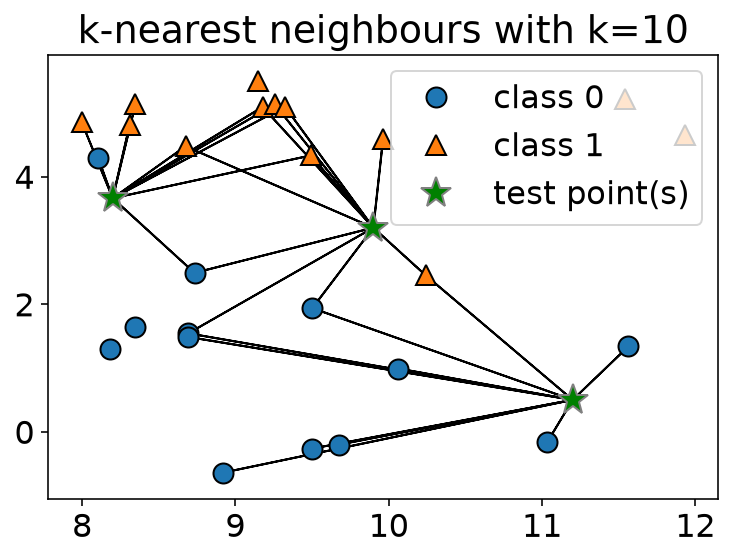
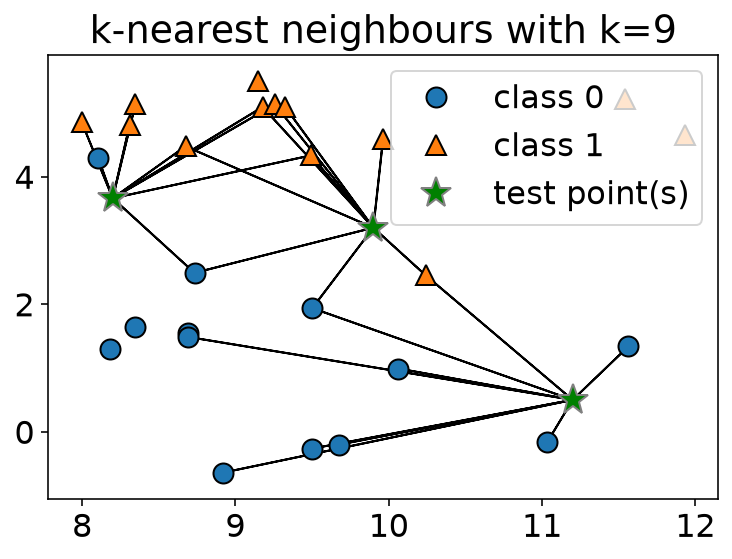
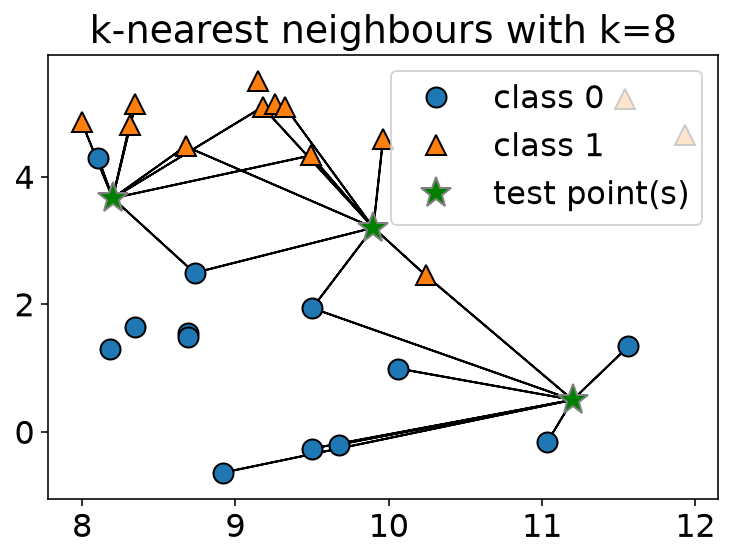
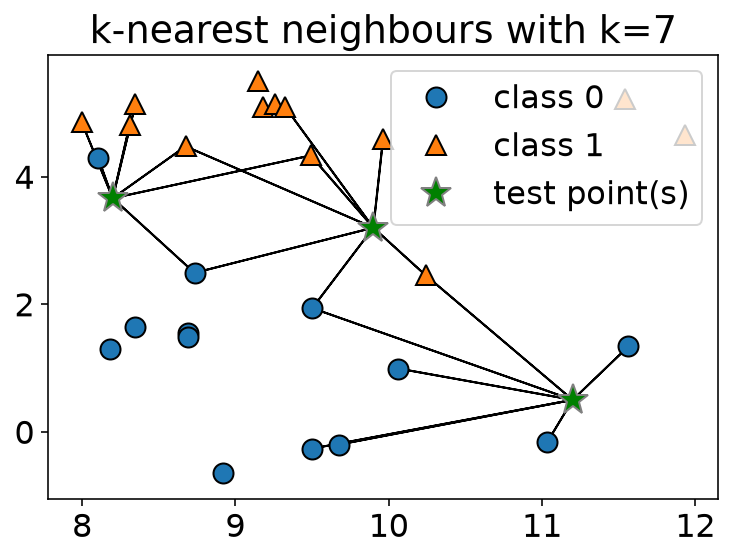
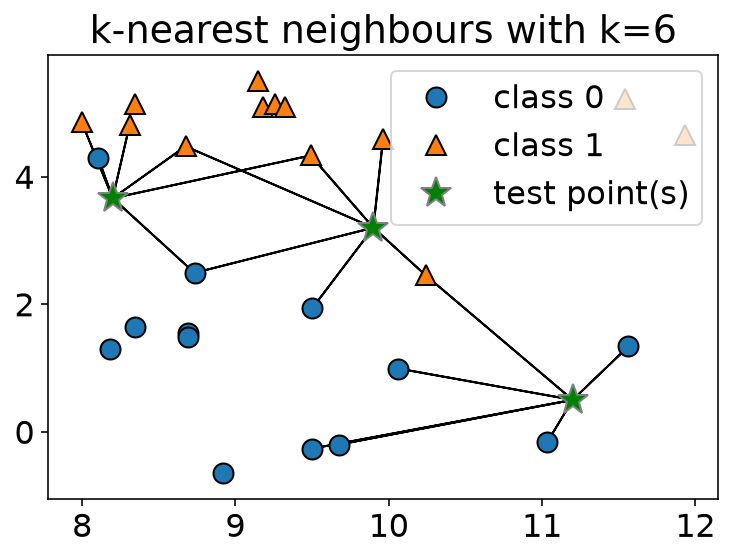
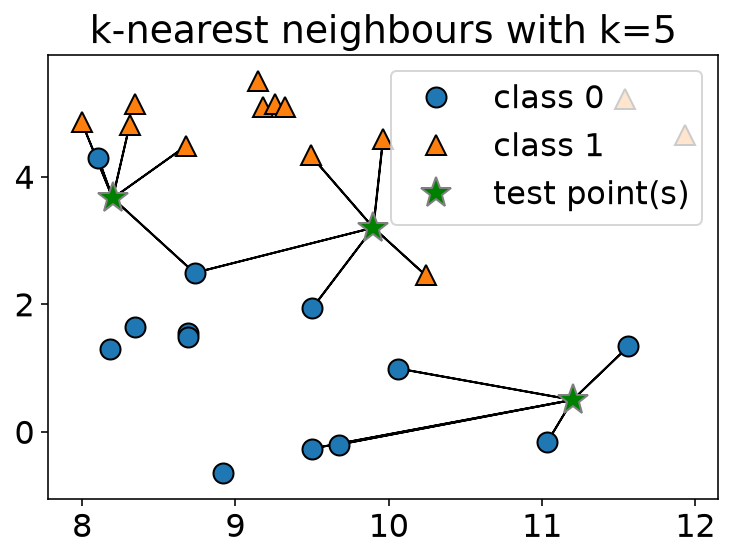
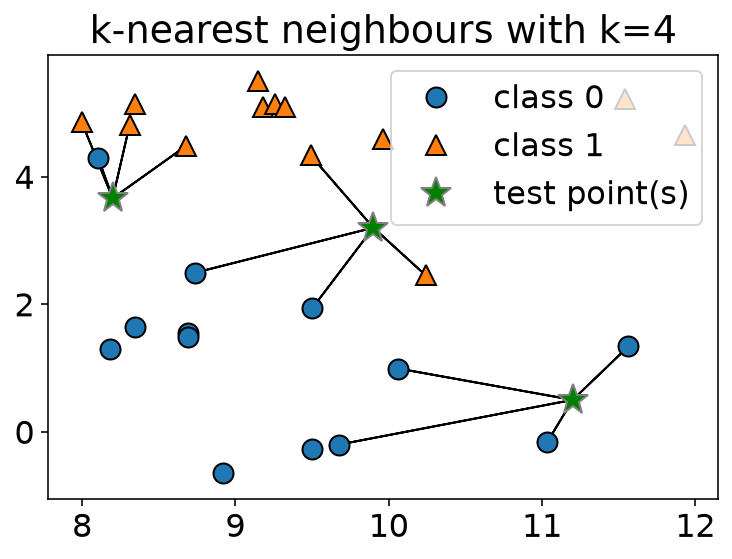
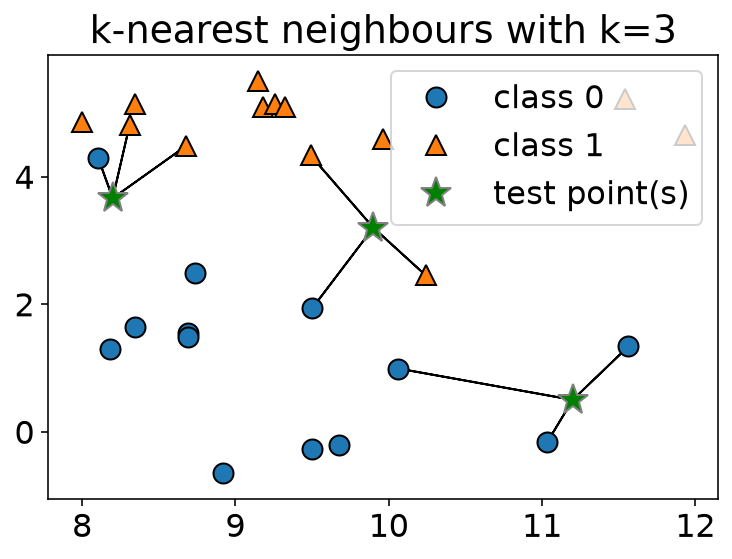
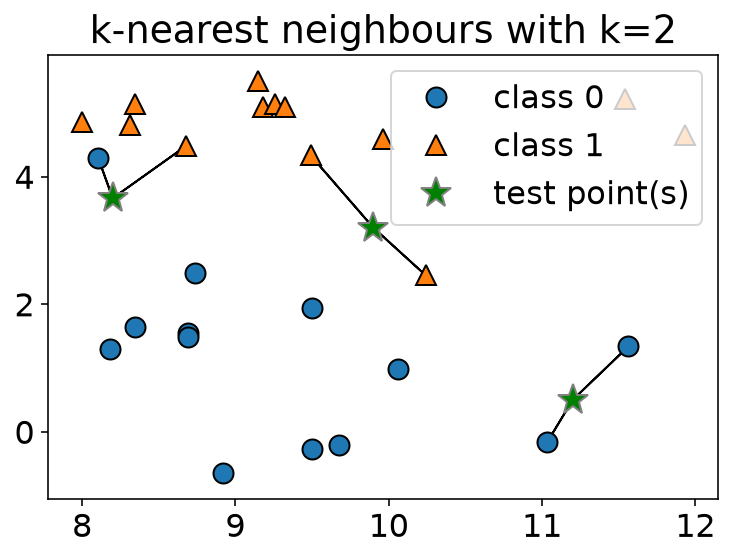
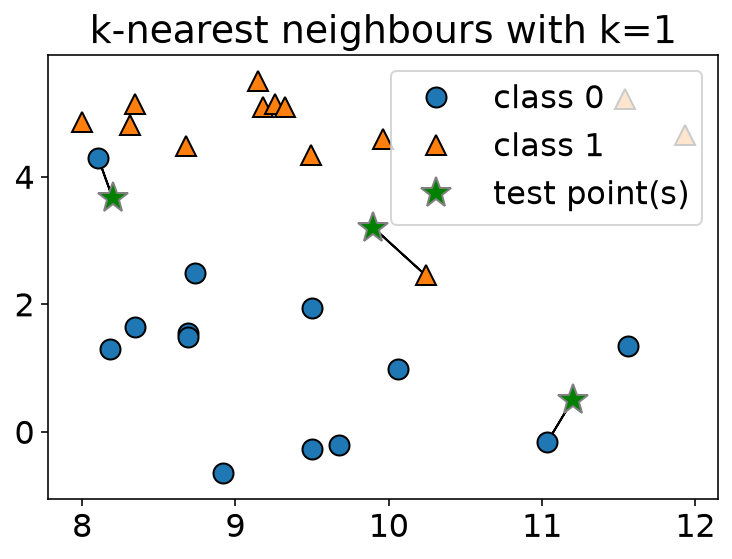

In [27]:
X_forge, y_forge = mglearn.datasets.make_forge()
X_forge_query = np.array([[8.2, 3.66214339], [9.9, 3.2], [11.2, 0.5]])

k_slider = pn.widgets.IntSlider(name="number of neighbours (k)", start=1, end=10, value=1)

def knn_figure(k):
    fig = plt.figure(figsize=(6, 4))
    plot_knn_clf(X_forge, y_forge, X_forge_query, n_neighbors=k)
    plt.title(f"k-nearest neighbours with k={k}")
    plt.close(fig)
    return pn.pane.Matplotlib(fig, tight=True)

knn_panel = pn.Column(k_slider, pn.bind(knn_figure, k_slider))
knn_panel.embed(states={k_slider: list(range(1, 11))}, json=False)

### Selecting $k$ with cross-validation

We should not choose $k$ by looking at the test score or by selecting whichever boundary looks appealing. Following Chapter 3, we first reserve a test set and use cross-validation only on the training set.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cities, y_cities, test_size=0.2, random_state=123, stratify=y_cities
)

results = []
for k in range(1, 50, 5):
    scores = cross_validate(
        KNeighborsClassifier(n_neighbors=k),
        X_train,
        y_train,
        return_train_score=True,
    )
    results.append(
        {
            "n_neighbors": k,
            "mean_train_score": scores["train_score"].mean(),
            "mean_cv_score": scores["test_score"].mean(),
            "std_cv_score": scores["test_score"].std(),
        }
    )

results_df = pd.DataFrame(results).set_index("n_neighbors")
results_df

,mean_train_score,mean_cv_score,std_cv_score
n_neighbors,,,
1,1.000000,0.711943,0.052087
6,0.818853,0.802496,0.023163
11,0.799439,0.784492,0.039660
16,0.764976,0.772549,0.029968
21,0.753002,0.742424,0.056442
26,0.736562,0.736720,0.050856
31,0.712558,0.718717,0.034810
36,0.720065,0.724599,0.039579
41,0.691583,0.670588,0.054224


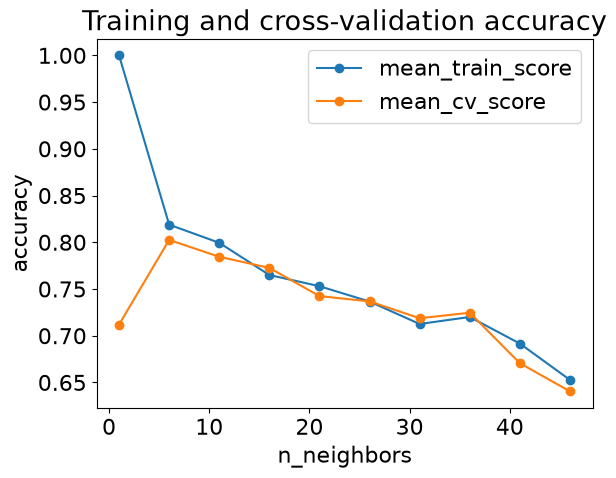

In [29]:
results_df[["mean_train_score", "mean_cv_score"]].plot(marker="o")
plt.ylabel("accuracy")
plt.title("Training and cross-validation accuracy");

Training accuracy is highest for the smallest values of $k$. Cross-validation performance identifies a value that better balances underfitting and overfitting. Once selected, we refit that configuration on the complete training set and evaluate it once on the test set.

In [30]:
best_k = int(results_df["mean_cv_score"].idxmax())
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

print(f"Selected k: {best_k}")
print(f"Mean cross-validation accuracy: {results_df.loc[best_k, 'mean_cv_score']:.3f}")
print(f"Test accuracy: {knn.score(X_test, y_test):.3f}")

Selected k: 6
Mean cross-validation accuracy: 0.802
Test accuracy: 0.857


The test and cross-validation scores need not match. Both estimate performance using finite samples, so differences caused by which examples appear in each subset are expected. The test result remains informative because it did not influence our selection of $k$.

::: {.callout-question}
<div class="exercise-title">Exercise 4.1: Distance and model complexity</div>

Select all true statements. Assume uniform voting unless stated otherwise.

- (A) A $k$-NN model searches the test set for examples similar to its query.
- (B) Changing the units of one feature can change which training example is nearest.
- (C) Increasing $k$ usually makes the decision boundary more flexible.
- (D) Much higher training accuracy than validation accuracy can indicate that $k$ is too small.
- (E) If $k$ includes the complete training set, predictions approach the overall majority class.
:::

::: {.callout-tip collapse="true" title="Solution"}
B, D, and E are true. The model compares a query with training examples. Larger values of $k$ generally make the boundary less flexible.
:::

### Uniform and distance-weighted neighbours

The default `weights="uniform"` gives every selected neighbour one vote. With `weights="distance"`, closer neighbours receive more influence than farther ones. Weighting changes the prediction rule and is therefore another hyperparameter choice to evaluate using validation data.

### $k$-NN regression

Suppose we want to predict the price of a house. Nearby houses in feature space do not vote for a class; instead, their prices provide plausible values for the new house. A `KNeighborsRegressor` predicts the mean target among the $k$ nearest training examples. With distance weighting, closer neighbours contribute more strongly to that mean.

The example below has one input feature, so we can plot the entire prediction function. Each dot is a training example, and the orange line shows the prediction at each feature value.

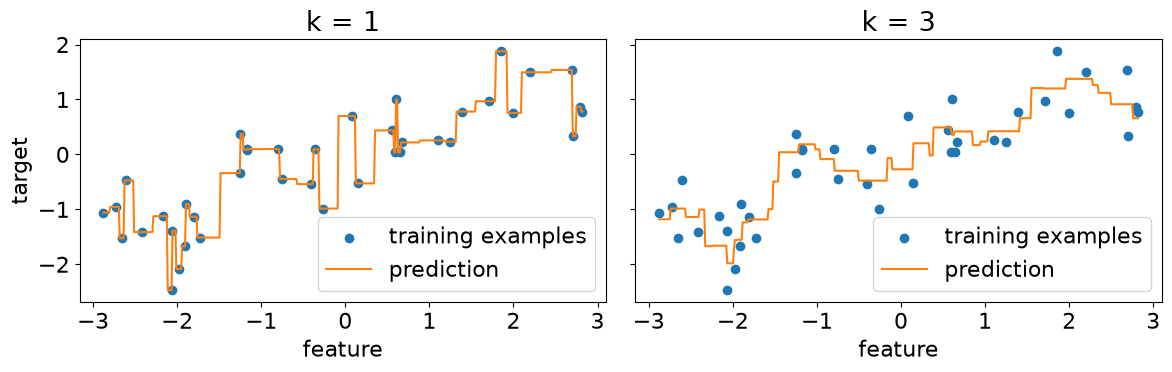

In [31]:
X_wave, y_wave = mglearn.datasets.make_wave(n_samples=40)
X_grid = np.linspace(X_wave.min(), X_wave.max(), 500).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for k, ax in zip([1, 3], axes):
    regressor = KNeighborsRegressor(n_neighbors=k).fit(X_wave, y_wave)
    ax.scatter(X_wave[:, 0], y_wave, label="training examples")
    ax.plot(X_grid[:, 0], regressor.predict(X_grid), color="tab:orange", label="prediction")
    ax.set_title(f"k = {k}")
    ax.set_xlabel("feature")
    ax.legend()
axes[0].set_ylabel("target")
plt.tight_layout()

With $k=1$, the prediction is simply the target of the nearest training example. The line changes abruptly whenever a different example becomes nearest, making the model sensitive to individual training points.

With $k=3$, each prediction averages three nearby targets. The result is smoother and less sensitive to any one example, but it can also hide real local variation. This is the same flexibility trade-off we saw in classification: small $k$ can overfit, while large $k$ can underfit. We therefore choose $k$ using validation data rather than selecting it from the training plot.

### Practical trade-offs

$k$-NN is attractive because its prediction rule is concrete, it can learn complicated boundaries, and fitting is usually inexpensive: the model mainly validates and stores the training data.

That design shifts work to prediction. To classify a query, the model may need to compare it with many stored examples, so prediction and storage can become costly as the training set grows. Its performance also depends strongly on feature scale, irrelevant features, the distance measure, and the overall representation.

**Computational note:** A naive $k$-NN prediction computes the distance from the query point to every training example. Data structures such as **kd-trees** can make neighbour lookup faster in some settings, particularly when there are few features. They tend to become less effective in high-dimensional spaces. See scikit-learn’s [`KDTree` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KDTree.html).

### The curse of dimensionality

Suppose two cities are close in longitude and latitude. If we add many unrelated numerical features, each one contributes an accidental difference to their distance. The cities can then appear far apart even though they are similar in the ways that matter.

More generally, a fixed number of examples becomes increasingly spread out as the number of dimensions grows. Nearby examples become harder to find, and the difference between the nearest and farthest examples can become less meaningful. This collection of problems is called the **curse of dimensionality**. It is especially troublesome for $k$-NN because its predictions depend directly on distance.

The experiment below keeps 2,000 examples and two informative features, then adds irrelevant features.

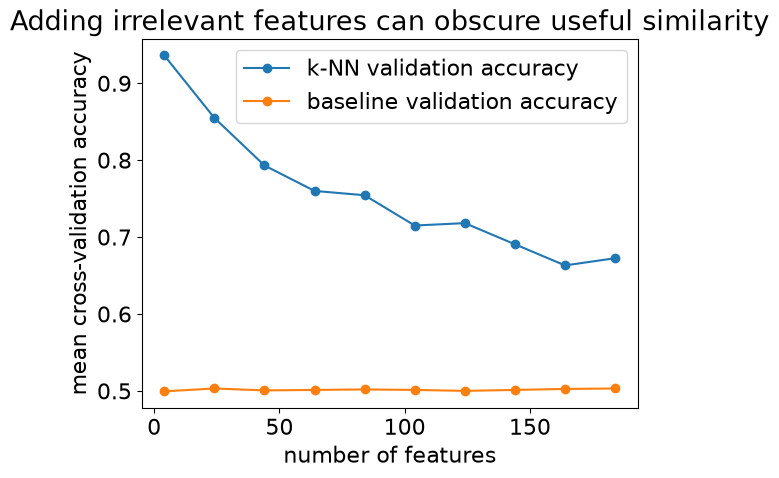

In [32]:
from sklearn.datasets import make_classification

rng_results = []
for n_features in range(4, 204, 20):
    X_dim, y_dim = make_classification(
        n_samples=2000,
        n_features=n_features,
        n_informative=2,
        n_redundant=0,
        n_repeated=0,
        n_classes=2,
        random_state=123,
    )
    X_dim_train, _, y_dim_train, _ = train_test_split(
        X_dim, y_dim, test_size=0.2, random_state=123, stratify=y_dim
    )
    knn_scores = cross_validate(KNeighborsClassifier(), X_dim_train, y_dim_train)
    dummy_scores = cross_validate(
        DummyClassifier(strategy="most_frequent"), X_dim_train, y_dim_train
    )
    rng_results.append(
        {
            "number of features": n_features,
            "k-NN validation accuracy": knn_scores["test_score"].mean(),
            "baseline validation accuracy": dummy_scores["test_score"].mean(),
        }
    )

dimension_results = pd.DataFrame(rng_results).set_index("number of features")
dimension_results.plot(marker="o")
plt.ylabel("mean cross-validation accuracy")
plt.title("Adding irrelevant features can obscure useful similarity");

As irrelevant features are added, $k$-NN's validation accuracy falls toward the dummy classifier's baseline. The useful information has not been removed; it has been overwhelmed by noise in the distance calculation. The plot illustrates why adding features can make a model worse and why feature selection and representation matter for distance-based models.

::: {.callout-question}
<div class="exercise-title">Exercise 4.2: Choosing a representation</div>

A dataset describes houses using floor area, number of bedrooms, postal code, and the listing agent's identification number. Before using Euclidean $k$-NN, explain which features require scaling, which might need a different representation, and which may be irrelevant or actively misleading.
:::

::: {.callout-tip collapse="true" title="Discussion"}
Floor area and bedroom count require attention to scale. Postal code is not an ordinary numerical measurement: numerical closeness between codes need not mean geographic closeness. The agent identifier is an arbitrary label and may inject meaningless differences. The right treatment depends on the prediction problem, but passing all four raw numbers directly to Euclidean distance is difficult to justify.
:::

## RBF support vector machines

$k$-NN predicts by consulting nearby training examples directly and letting them vote. This produces an intuitive model, but it can create jagged boundaries and make prediction expensive. An **RBF support vector machine (SVM)** also uses similarity, but it learns a different kind of prediction rule. During fitting, it identifies training examples that are especially important for determining the decision boundary. These examples are called **support vectors**.

Our goal here is deliberately operational. We will not derive the SVM optimization problem or the kernel trick. We want enough intuition to use scikit-learn’s support vector classifier ([`SVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)) and regressor ([`SVR`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html)), recognize support vectors, and reason about the gamma and C hyperparameters of an RBF SVM.

### From distance to RBF similarity

The radial basis function (RBF) kernel converts distance into similarity. Two examples that are close have an RBF similarity near one. As their squared Euclidean distance grows, their similarity approaches zero. The RBF kernel is therefore a **similarity function built from distance**, not another distance metric.

To classify a query, the fitted model measures its RBF similarity to the support vectors and combines their influences. Support vectors from the two classes push the prediction in different directions, and the resulting score determines the predicted class.

It can be helpful to picture an RBF SVM as a smoother relative of $k$-NN, but this is only an analogy. A $k$-NN model selects neighbours and lets them vote at prediction time. An SVM selects support vectors and learns how strongly they contribute during fitting.

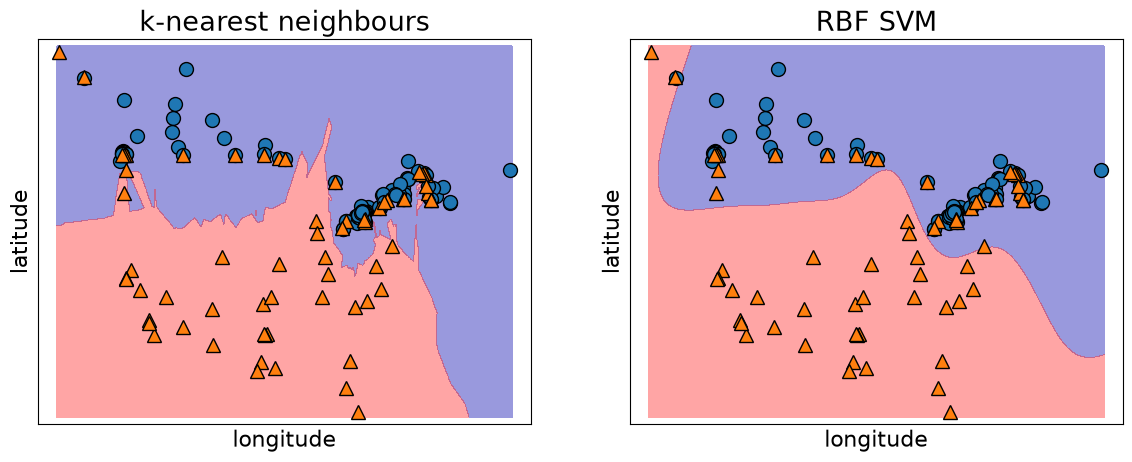

In [33]:
knn_for_comparison = KNeighborsClassifier(n_neighbors=best_k)
svm_for_comparison = SVC(kernel="rbf", gamma=0.01)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model, title, ax in zip(
    [knn_for_comparison, svm_for_comparison],
    ["k-nearest neighbours", "RBF SVM"],
    axes,
):
    model.fit(X_train, y_train)
    mglearn.plots.plot_2d_separator(
        model, X_train.to_numpy(), fill=True, eps=0.5, ax=ax, alpha=0.4
    )
    mglearn.discrete_scatter(
        X_train.iloc[:, 0], X_train.iloc[:, 1], y_train, ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")

### Support vectors

Support vectors are often training examples close to the decision boundary because such examples help determine exactly where the boundary should go. In the cities problem, a city far inside Canada tells us relatively little about the precise location of the Canada–USA boundary. Cities near the border, such as White Rock or Buffalo, are potentially much more informative.

This is useful intuition rather than a complete definition. Difficult or misclassified examples can also be support vectors, and an SVM does not necessarily end up with only a small number of them. More precisely, support vectors are the training examples that contribute directly to the fitted decision function. Whether an example becomes a support vector is determined during `fit`. The highlighted examples below are the support vectors for this fitted model.

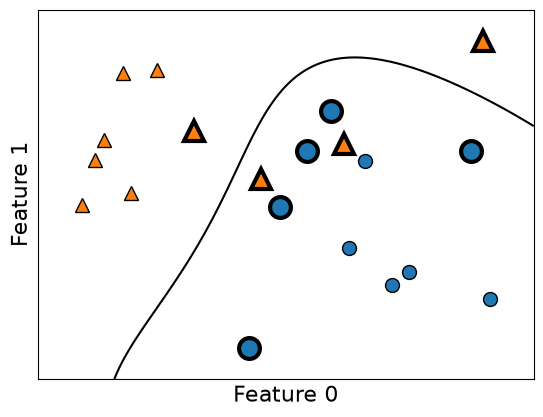

In [34]:
from sklearn.datasets import make_blobs

X_toy, y_toy = make_blobs(n_samples=20, centers=2, random_state=300)
svm_toy = SVC(kernel="rbf", C=10, gamma=0.1).fit(X_toy, y_toy)
plot_support_vectors(svm_toy, X_toy, y_toy)

### Optional: the decision function

For binary classification, the preceding description can be written as

$$
f(x_{\text{new}}) = \sum_{i \in SV} \alpha_i y_i K(x_i, x_{\text{new}}) + b.
$$

Here $x_i$ is a support vector, $y_i$ indicates its class, $\alpha_i$ determines how strongly it contributes, $K(x_i,x_{\text{new}})$ measures its similarity to the query, and $b$ shifts the decision threshold. The sign of the resulting score determines the predicted class.

You are not expected to calculate this function by hand. Its purpose is to make the main idea precise: an RBF SVM combines learned contributions from support vectors rather than taking a neighbour vote.

### `gamma`: how local is the similarity?

The RBF similarity between a support vector $x_i$ and a query $x_{\text{new}}$ is

$$
K(x_i,x_{\text{new}}) = \exp\left(-\gamma \lVert x_i-x_{\text{new}} \rVert^2\right).
$$

The value is 1 when the two feature vectors are identical and approaches 0 as they move farther apart. You can imagine placing a smooth bump over each support vector. The bump is highest at the support vector and falls as we move away; the similarity is the height of the bump at the query.

`gamma` controls the width of these bumps:

- A small `gamma` creates wide bumps, so each support vector influences a broad region. This usually produces a smoother boundary.
- A large `gamma` creates narrow bumps, so each support vector has highly local influence. This allows a more detailed boundary.

As a broad tendency, increasing `gamma` increases flexibility and can move the model from underfitting toward overfitting. Because RBF similarity is calculated from distance, feature scaling affects these regions of influence.

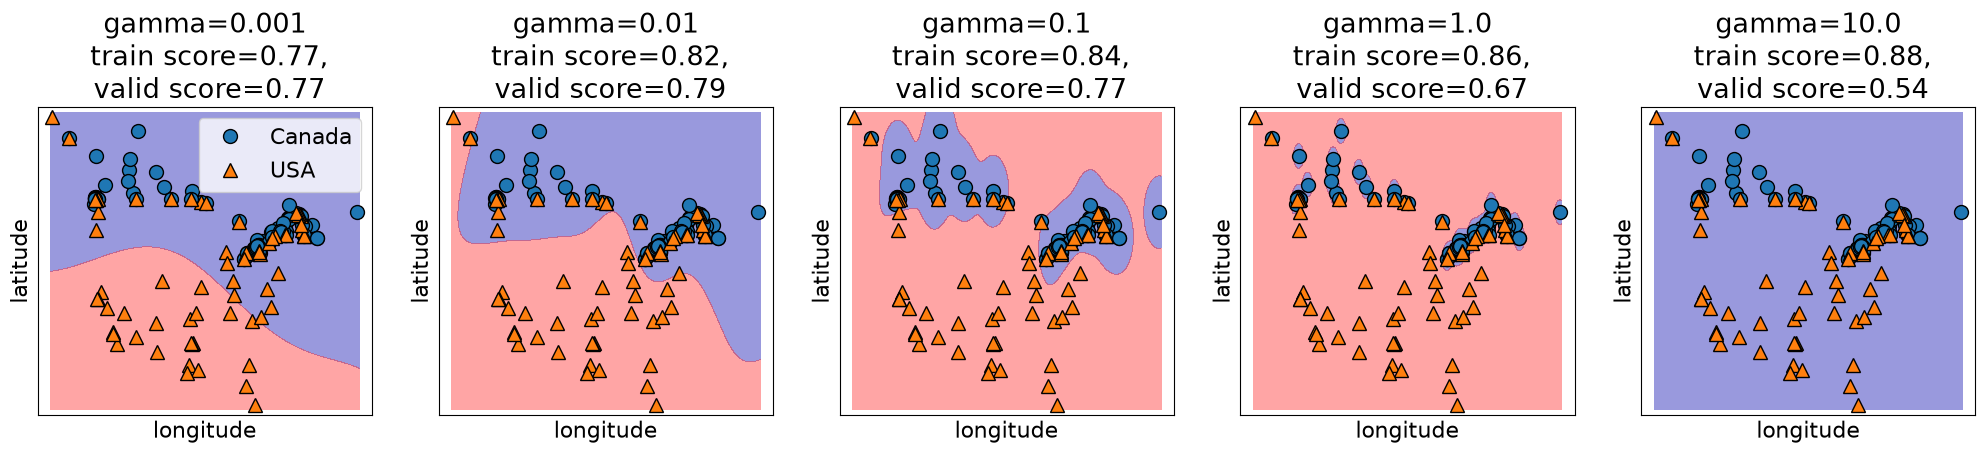

In [35]:
gamma_values = [0.001, 0.01, 0.1, 1.0, 10.0]
plot_svc_gamma(
    gamma_values,
    X_train.to_numpy(),
    y_train.to_numpy(),
    x_label="longitude",
    y_label="latitude",
)

### `C`: how costly are training mistakes?

`C` controls how strongly fitting penalizes mistakes on the training data.

- A small `C` tolerates more training mistakes, allowing a smoother boundary. If `C` is too small, the model may underfit.
- A large `C` puts more pressure on the model to classify difficult training examples correctly, often producing a more detailed boundary. If `C` is too large, the model may overfit.

This is again a broad tendency rather than a guarantee about validation performance.

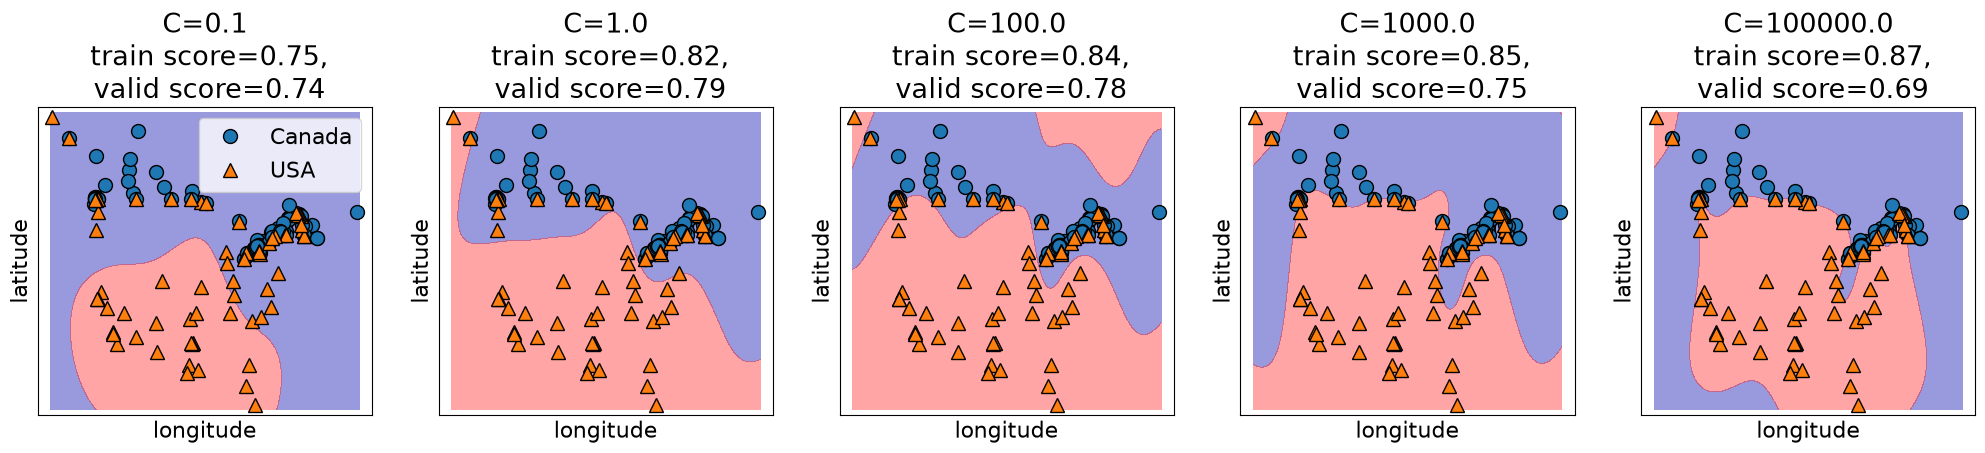

In [36]:
C_values = [0.1, 1.0, 100.0, 1000.0, 100000.0]
plot_svc_C(
    C_values,
    X_train.to_numpy(),
    y_train.to_numpy(),
    x_label="longitude",
    y_label="latitude",
)

### Why `C` and `gamma` must be tuned together

The two hyperparameters answer different questions:

- `gamma`: How far does each support vector's influence extend?
- `C`: How strongly should fitting try to avoid training mistakes?

Their effects interact. Changing the penalty for mistakes can have a different effect when every support vector has broad influence than when each has highly local influence. We therefore cannot reliably tune one, freeze it, and then tune the other.

A later chapter will introduce tools such as `GridSearchCV` and `RandomizedSearchCV` for evaluating combinations of hyperparameters. The same Golden Rule still applies: the search uses training and validation data, while the test set remains untouched until the complete workflow has been selected.

### Comparing the two models

| Question | $k$-NN | RBF SVM |
|---|---|---|
| How is distance used? | It selects the nearest training examples. | Squared Euclidean distance determines RBF similarity. |
| What happens during fitting? | The model mainly stores the training examples. | The model selects support vectors and learns how strongly they contribute. |
| How is a classification prediction formed? | The selected neighbours vote. | Learned, weighted similarities are combined. |
| Main hyperparameters here | `n_neighbors`, `weights` | `C`, `gamma` |
| Main computational concern | Prediction can be costly for large training sets. | Fitting can be costly for large datasets. |

Neither model is universally better. Their performance depends on the representation, sample size, hyperparameters, and structure of the problem.

### Classification, regression, and text data

Just as scikit-learn provides `KNeighborsClassifier` and `KNeighborsRegressor`, it provides `SVC` for classification and `SVR` for regression.

RBF SVMs can learn nonlinear decision boundaries and often work well on appropriately preprocessed small- to medium-sized datasets. Fitting can become expensive as the number of examples grows, and the results are sensitive to feature scaling, `C`, and `gamma`.

SVMs can also be effective with high-dimensional text representations. For large sparse text datasets, a linear SVM is often a more scalable baseline than an RBF SVM. We retain the RBF model here because it makes similarity visible and provides two interacting hyperparameters for practice. The next chapter will show how text and other non-numerical columns can be transformed as part of a complete modeling pipeline.

::: {.callout-question}
<div class="exercise-title">Exercise 4.3: Reasoning about an RBF SVM</div>

Select all true statements.

- (A) Increasing `gamma` makes each training example's RBF influence more local.
- (B) Increasing `C` always improves validation accuracy.
- (C) The best `C` can depend on the selected `gamma`.
- (D) An RBF kernel is a distance metric.
- (E) An RBF SVM uses all nearby examples in an unweighted majority vote.
:::

::: {.callout-tip collapse="true" title="Solution"}
A and C are true. Larger `C` may overfit, an RBF kernel is a similarity function built from distance, and an SVM combines learned weighted similarities rather than using a $k$-NN vote.
:::

## Summary

- A numerical example can be represented as a point in feature space, but closeness depends on the selected features, their encodings, their scales, and the distance measure.
- $k$-NN classification uses a vote among nearby training examples; $k$-NN regression averages their targets.
- Small $k$ usually produces a more flexible model, while large $k$ produces a smoother model that can underfit.
- Feature scaling, irrelevant features, and high dimensionality can make Euclidean distance misleading.
- An RBF SVM selects support vectors and learns how strongly they contribute, rather than using a direct neighbour vote.
- `gamma` controls how local RBF influence is, while `C` controls how strongly training mistakes are penalized. Their interaction means they should be tuned jointly.

Similarity-based models are only as meaningful as the representation on which similarity is computed. Real datasets contain features with incompatible scales, categories, missing values, and text. The next chapter develops pipelines and column transformers for building those representations without leaking information across data splits.

![](img/eva-seeyou.png)